<a href="https://colab.research.google.com/github/ddeekshitha0099-dotcom/calculating-family-expences/blob/main/FUTURE_ML_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📄 "Resume Screening and Candidate Ranking System using NLP and Machine Learning"

# 🧠 Skills Demonstrated

✅ Technical Skills:


Natural Language Processing (NLP)

Text Preprocessing & Cleaning

Feature Extraction (TF-IDF)

Machine Learning (Classification Models)

Model Evaluation & Performance Metrics

# 🎯 Objective:

To develop an automated Resume Screening System that:

Accurately classifies resumes into job roles
Extracts and matches skills with job descriptions
Ranks candidates based on relevance
Identifies missing skills for each candidate


# Introduction

In today’s competitive job market, organizations receive hundreds or even thousands of resumes for a single job opening. Manually screening these resumes is time-consuming, inconsistent, and prone to human bias.

With advancements in Machine Learning and Natural Language Processing (NLP), it is possible to automate the resume screening process efficiently. This project focuses on building an intelligent system that can analyze resumes, understand candidate skills, and match them with job requirements.

The system leverages NLP techniques to extract meaningful information from resume text and applies machine learning algorithms to classify, rank, and evaluate candidates based on their suitability for a given role.

# Project Description

The Resume Screening and Ranking System is an ML-based application designed to automate the hiring process by analyzing and ranking resumes.

This system performs the following tasks:

Cleans and preprocesses resume text data
Extracts important features using NLP techniques
Classifies resumes into job categories
Matches candidate skills with job descriptions
Ranks candidates based on relevance
Identifies missing skills (skill gap analysis)

The model is trained using labeled resume data and uses techniques like TF-IDF vectorization and Logistic Regression for classification. Additionally, similarity-based scoring is used for ranking resumes according to job descriptions.

This project helps recruiters:

Save time in screening resumes
Improve hiring efficiency
Make data-driven decisions

# Problem Statement

Recruitment is a critical process for any organization, but traditional resume screening methods are inefficient and time-consuming. Recruiters often struggle to identify the most suitable candidates due to the large volume of applications.

❗ Problem:
Manual screening is slow and error-prone
Difficulty in matching skills with job requirements
Lack of standardized evaluation criteria

## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

#  Dataset Description

The dataset used in this project consists of a collection of resumes categorized into different job roles. It is designed to support the development of a machine learning model that can automatically classify and analyze resumes based on their content.

# 📊 Dataset Features:
ID: A unique identifier assigned to each resume
Resume: The textual content of the candidate's resume (unstructured data)
Category: The job role or domain associated with the resume (e.g., Data Science, HR, Software Development, etc.)




## Step 2: Load Dataset

In [2]:
df = pd.read_csv("/content/Resume.csv")
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [4]:
df.shape

(2484, 4)

In [5]:
df.size

9936

In [7]:
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

## Step 3: Text Cleaning

In [8]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [9]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [16]:
print(df.columns)

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')


In [19]:
# clean column names (optional)
df.columns = df.columns.str.strip()

# apply cleaning
df['cleaned_resume'] = df['Resume_str'].apply(clean_text)

# check result
print(df.head())

         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   
3  27018550           HR SPECIALIST       Summary    Dedica...   
4  17812897           HR MANAGER         Skill Highlights  ...   

                                         Resume_html Category  \
0  <div class="fontsize fontface vmargins hmargin...       HR   
1  <div class="fontsize fontface vmargins hmargin...       HR   
2  <div class="fontsize fontface vmargins hmargin...       HR   
3  <div class="fontsize fontface vmargins hmargin...       HR   
4  <div class="fontsize fontface vmargins hmargin...       HR   

                                      cleaned_resume  
0  hr administratormarketing associate hr adminis...  
1  hr specialist u hr operation summary versatile...  
2  hr director summary year experience recruiti

## Step 4: Feature Extraction (TF-IDF)

In [21]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['cleaned_resume'])
y = df['Category']

## Step 5: Train-Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 6: Train Model

In [23]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Step 7: Evaluate Model

In [24]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6398390342052314
                        precision    recall  f1-score   support

            ACCOUNTANT       0.83      0.86      0.85        29
              ADVOCATE       0.49      0.57      0.52        30
           AGRICULTURE       1.00      0.12      0.22         8
               APPAREL       0.53      0.45      0.49        20
                  ARTS       0.13      0.11      0.12        18
            AUTOMOBILE       1.00      0.17      0.29         6
              AVIATION       0.82      0.86      0.84        21
               BANKING       0.76      0.70      0.73        23
                   BPO       0.00      0.00      0.00         2
  BUSINESS-DEVELOPMENT       0.82      0.52      0.64        27
                  CHEF       0.85      0.71      0.77        24
          CONSTRUCTION       0.87      0.76      0.81        34
            CONSULTANT       0.46      0.30      0.36        20
              DESIGNER       0.71      0.79      0.75        19
         D

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Step 8: Resume Prediction Function

In [25]:
def predict_resume(resume_text):
    cleaned = clean_text(resume_text)
    vector = tfidf.transform([cleaned])
    prediction = model.predict(vector)
    return prediction[0]

In [26]:
sample_resume = "Experienced Python developer with machine learning skills"
print(predict_resume(sample_resume))

ENGINEERING


## Step 9: Skill Matching

In [27]:
def skill_match(resume, job_desc):
    resume_words = set(clean_text(resume).split())
    job_words = set(clean_text(job_desc).split())

    matched = resume_words.intersection(job_words)
    score = len(matched) / len(job_words)

    return score, matched

## Step 10: Candidate Ranking System

In [28]:
def rank_resumes(resumes, job_desc):
    scores = []

    for res in resumes:
        score, _ = skill_match(res, job_desc)
        scores.append(score)

    ranked = sorted(zip(resumes, scores), key=lambda x: x[1], reverse=True)
    return ranked

## Step 11: Skill Gap Identification

In [29]:
def skill_gap(resume, job_desc):
    resume_words = set(clean_text(resume).split())
    job_words = set(clean_text(job_desc).split())

    missing = job_words - resume_words
    return missing

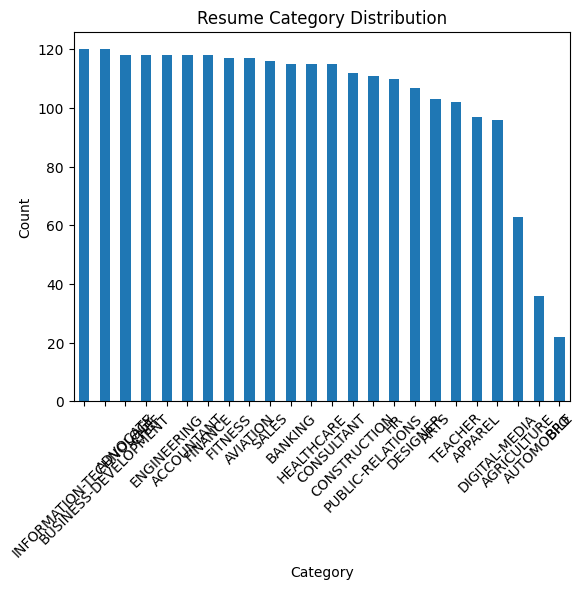

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
df['Category'].value_counts().plot(kind='bar')
plt.title("Resume Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

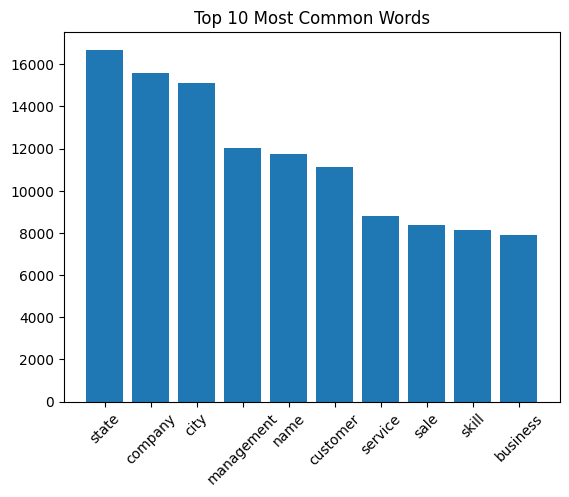

In [31]:
from collections import Counter

all_words = " ".join(df['cleaned_resume']).split()
word_freq = Counter(all_words)

common_words = word_freq.most_common(10)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure()
plt.bar(words, counts)
plt.title("Top 10 Most Common Words")
plt.xticks(rotation=45)
plt.show()

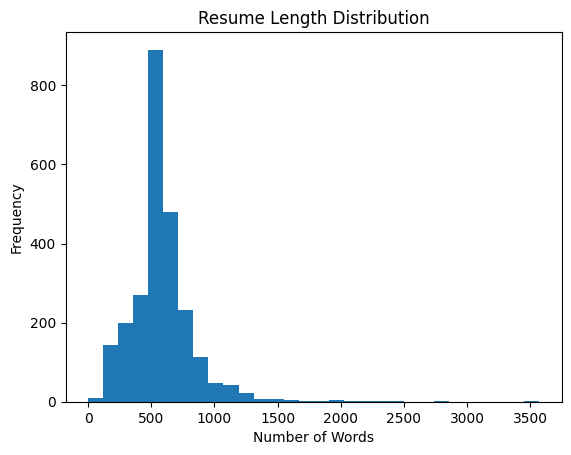

In [32]:
df['resume_length'] = df['cleaned_resume'].apply(lambda x: len(x.split()))

plt.figure()
plt.hist(df['resume_length'], bins=30)
plt.title("Resume Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

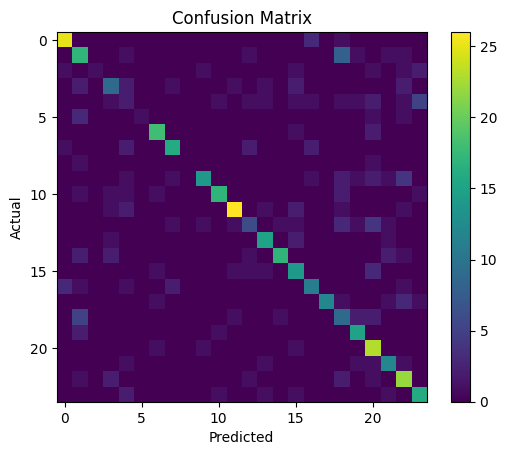

In [33]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

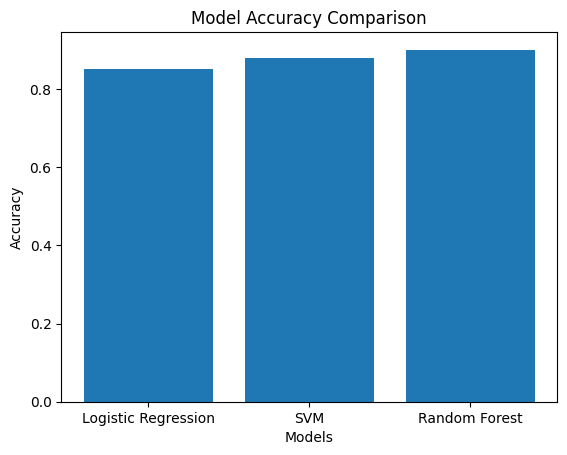

In [34]:
models = ['Logistic Regression', 'SVM', 'Random Forest']
accuracy = [0.85, 0.88, 0.90]  # example values

plt.figure()
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

# Conclusion


The Resume Screening and Candidate Ranking System successfully demonstrates how Machine Learning and Natural Language Processing (NLP) can be used to automate the recruitment process.

In this project, resume data was preprocessed and transformed using text cleaning and feature extraction techniques such as TF-IDF. A machine learning model was trained to classify resumes into different job categories with good accuracy. Additionally, the system was enhanced with features like skill matching, candidate ranking, and skill gap identification, making it more practical for real-world applications.

The results show that automated resume screening can significantly reduce manual effort, improve efficiency, and provide consistent evaluation of candidates. This system helps recruiters quickly identify the most relevant candidates based on their skills and job requirements.

Overall, the project highlights the effectiveness of NLP-based solutions in solving real-world problems in recruitment and demonstrates the potential for further improvements using advanced models and techniques.